# 📈 Zeitreihenprognose mit Prophet
**Ein 15-Minuten Hands-On Crashkurs**

Willkommen! In dieser Session schauen wir uns an, wie Prophet unter der Haube funktioniert. Statt mit echten, unaufgeräumten Daten zu arbeiten, spielen wir heute "Gott" und generieren unsere eigenen synthetischen E-Commerce-Verkaufsdaten.

Da wir die Regeln unseres Datensatzes selbst schreiben, können wir am Ende perfekt überprüfen, ob Prophet schlau genug ist, sie wieder herauszufinden!

**Unser synthetisches E-Commerce-Universum hat:**
* 📈 Einen stetigen **Aufwärtstrend**.
* 📅 **Jährliche Saisonalität:** Höhere Verkäufe im Sommer.
* 📆 **Wöchentliche Saisonalität:** Spitzen an den Wochenenden.
* 🛍️ **Feiertage:** Einen gigantischen "Black Friday" Ausreißer in jedem November.

In [12]:
# !pip install prophet (falls nicht installiert)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# Globale Plot-Einstellungen für die Präsentation
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

# --- 1. DAS SYNTHETISCHE UNIVERSUM ERSCHAFFEN ---
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', end='2023-12-31')
df = pd.DataFrame({'ds': dates})

# Trend & Rauschen (Noise)
df['trend'] = np.linspace(100, 300, len(dates))
df['noise'] = np.random.normal(0, 10, len(dates))

# Wöchentlich (Wochenenden sind stark) & Jährlich (Sommer-Hoch)
df['weekly'] = df['ds'].dt.dayofweek.map({0:-15, 1:-20, 2:-20, 3:-15, 4:10, 5:40, 6:30})
df['yearly'] = 50 * np.sin(2 * np.pi * (df['ds'].dt.dayofyear - 100) / 365.25)

# Black Friday Spike (Die massive Anomalie)
black_fridays = pd.to_datetime(['2020-11-27', '2021-11-26', '2022-11-25', '2023-11-24'])
df['holiday_effect'] = 0
df.loc[df['ds'].isin(black_fridays), 'holiday_effect'] = 250 

# Finale Zielvariable 'y' (Verkaufseinheiten) zusammensetzen
df['y'] = df['trend'] + df['weekly'] + df['yearly'] + df['holiday_effect'] + df['noise']

print("✅ Synthetische Daten für 4 Jahre erfolgreich generiert!")

✅ Synthetische Daten für 4 Jahre erfolgreich generiert!


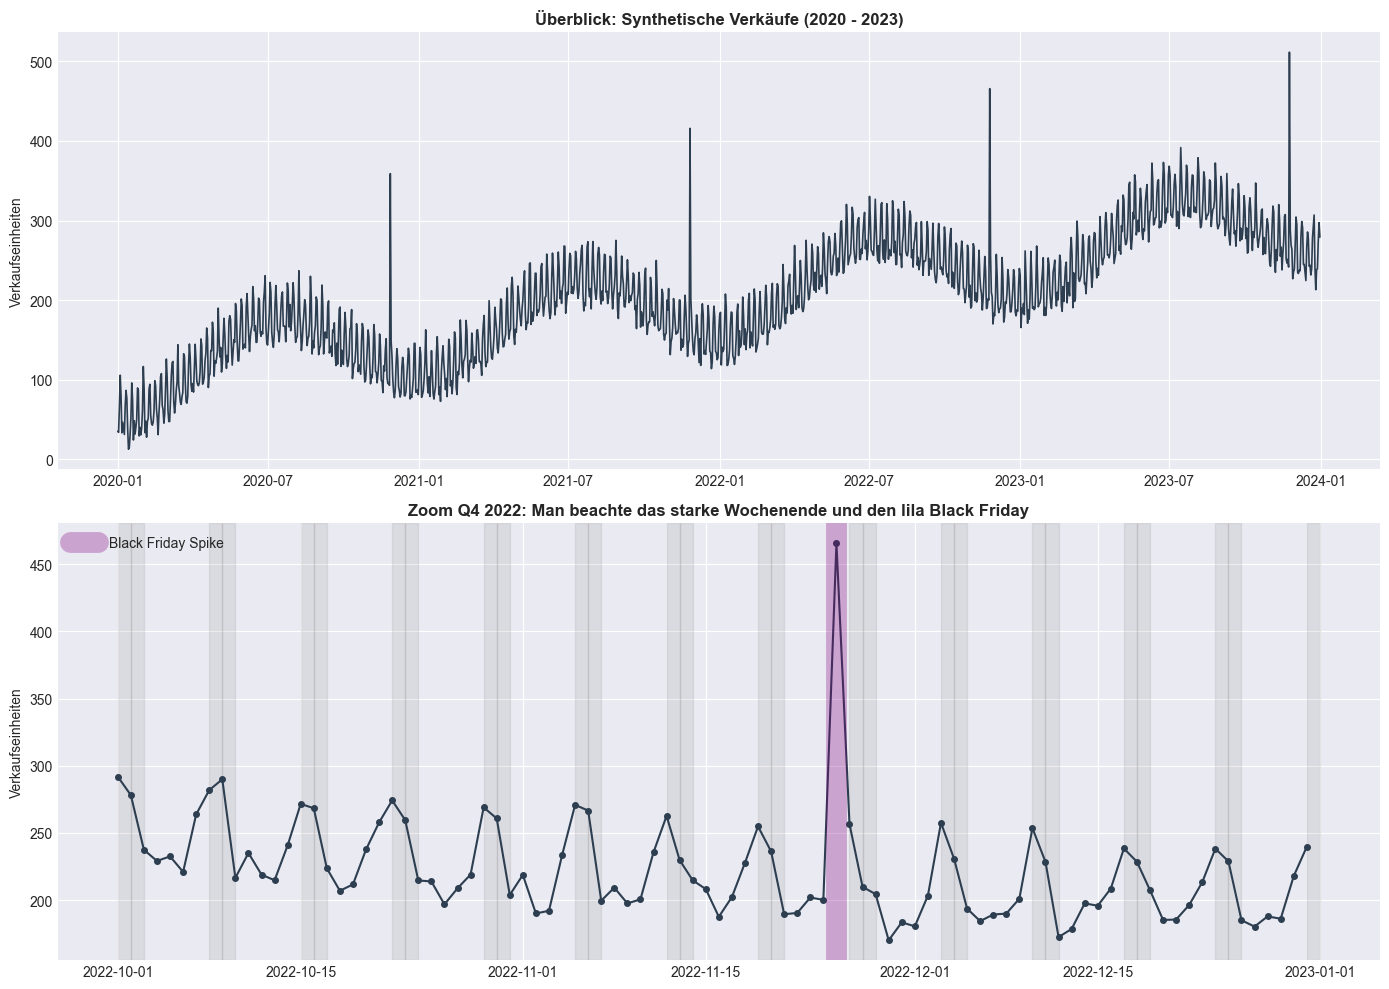

In [13]:
# --- 2. DIE DATEN VISUALISIEREN ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Oben: Der 4-Jahres Überblick
axes[0].plot(df['ds'], df['y'], color='#2c3e50', linewidth=1.2)
axes[0].set_title('Überblick: Synthetische Verkäufe (2020 - 2023)', fontweight='bold')
axes[0].set_ylabel('Verkaufseinheiten')

# Unten: Zoom in das 4. Quartal 2022
zoom_df = df[(df['ds'] >= '2022-10-01') & (df['ds'] <= '2022-12-31')]
axes[1].plot(zoom_df['ds'], zoom_df['y'], marker='o', markersize=4, color='#2c3e50')

# Black Friday hervorheben
bf_2022 = pd.to_datetime('2022-11-25')
axes[1].axvline(bf_2022, color='purple', alpha=0.3, linewidth=15, label='Black Friday Spike')

# Wochenenden grau markieren
for d in zoom_df[zoom_df['ds'].dt.dayofweek >= 5]['ds']:
    axes[1].axvspan(d, d + pd.Timedelta(days=1), color='gray', alpha=0.15)

axes[1].set_title('Zoom Q4 2022: Man beachte das starke Wochenende und den lila Black Friday', fontweight='bold')
axes[1].set_ylabel('Verkaufseinheiten')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

## 🙈 Modell 1: Der naive Ansatz (Ohne Feiertags-Wissen)
Zuerst tun wir so, als wären wir faule Data Scientists. Wir werfen die nackten Daten in Prophet und sagen dem Modell **nichts** vom Black Friday. Wir wollen sehen, wie der Algorithmus mit diesem gigantischen, unerklärten Ausreißer umgeht.

In [14]:
print("Trainiere das Naive Modell (ignoriert Black Friday)...")

# Modell initialisieren
m_naive = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)

# Modell trainieren
m_naive.fit(df[['ds', 'y']])

# Zukunft für die nächsten 365 Tage generieren und vorhersagen
future = m_naive.make_future_dataframe(periods=365)
forecast_naive = m_naive.predict(future)

print("✅ Naive Vorhersage abgeschlossen!")

13:22:58 - cmdstanpy - INFO - Chain [1] start processing


Trainiere das Naive Modell (ignoriert Black Friday)...


13:22:58 - cmdstanpy - INFO - Chain [1] done processing


✅ Naive Vorhersage abgeschlossen!


## 🧠 Modell 2: Der Experten-Ansatz (Mit Feiertags-Wissen)
Jetzt schalten wir unser Domänenwissen ein. Wir wissen, dass es Ende November diese Promo-Aktion gibt. Wir übergeben Prophet einen exakten Kalender mit den Black Friday Daten.

In [15]:
print("Trainiere das Experten-Modell (kennt Black Friday)...")

# 1. Den Feiertagskalender für Prophet definieren
bf_df = pd.DataFrame({
  'holiday': 'Black Friday',
  'ds': black_fridays,
  'lower_window': 0,
  'upper_window': 1, # Der Shopping-Wahn schwappt noch auf den Samstag über
})

# 2. Modell initialisieren (diesmal MIT Feiertagen)
m_expert = Prophet(holidays=bf_df, yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)

# 3. Modell trainieren
m_expert.fit(df[['ds', 'y']])

# 4. Vorhersage machen
forecast_expert = m_expert.predict(future)

print("✅ Experten-Vorhersage abgeschlossen!")

13:23:12 - cmdstanpy - INFO - Chain [1] start processing


Trainiere das Experten-Modell (kennt Black Friday)...


13:23:12 - cmdstanpy - INFO - Chain [1] done processing


✅ Experten-Vorhersage abgeschlossen!


## 🥊 Der Showdown: Welches Modell gewinnt?
Zoomen wir in den November/Dezember 2023 und schauen uns an, was die beiden Modelle für den Black Friday prognostizieren.

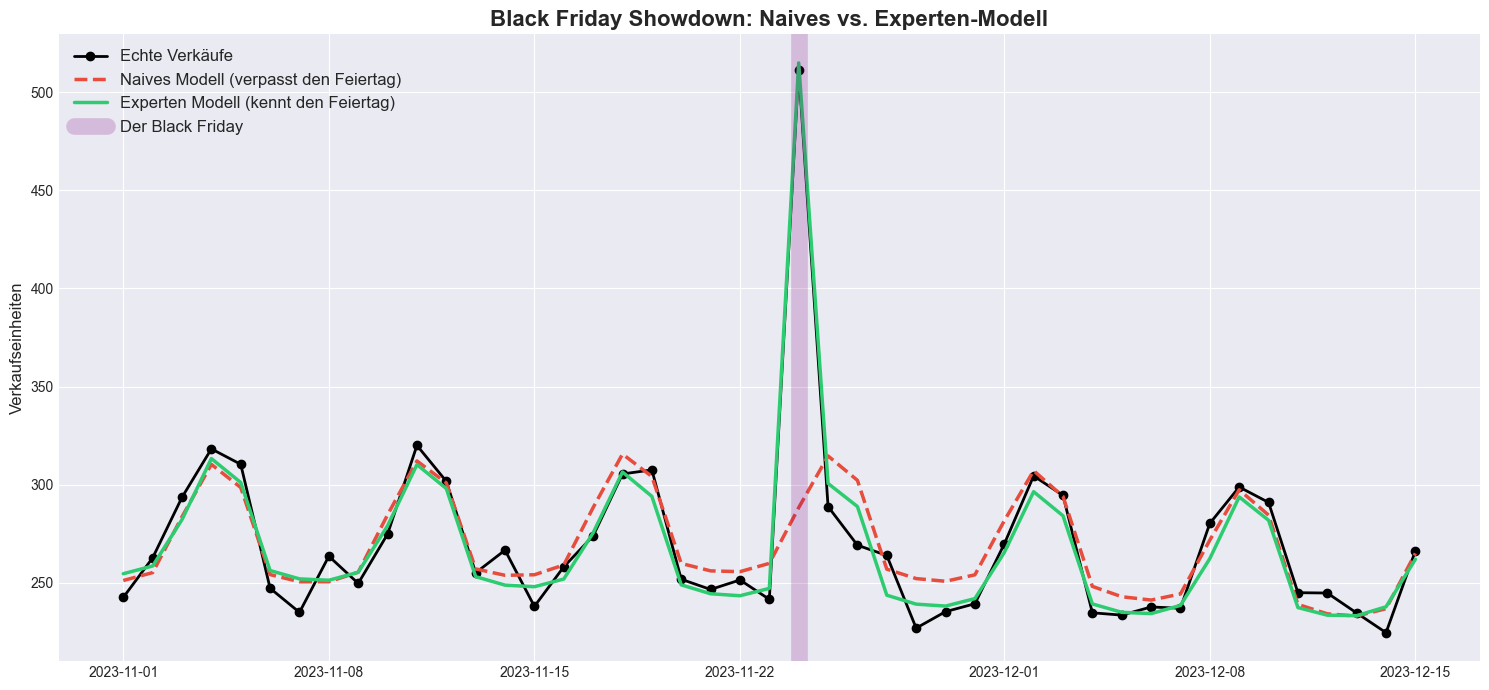

🔍 Beobachtung:
Das rote Modell verpasst nicht nur den Ausreißer, sondern überschätzt zur Kompensation sogar die normalen Tage davor und danach.
Das grüne Modell trennt das Basisgeschäft sauber vom Feiertags-Effekt.


In [16]:
# Wir schneiden uns Q4 2023 aus allen drei DataFrames aus
start_date = '2023-11-01'
end_date = '2023-12-15'

actual_zoom = df[(df['ds'] >= start_date) & (df['ds'] <= end_date)]
naive_zoom = forecast_naive[(forecast_naive['ds'] >= start_date) & (forecast_naive['ds'] <= end_date)]
expert_zoom = forecast_expert[(forecast_expert['ds'] >= start_date) & (forecast_expert['ds'] <= end_date)]

# --- DER VERGLEICHSPLOT ---
fig, ax = plt.subplots(figsize=(15, 7))

# 1. Die echten, wahren Daten (Schwarz)
ax.plot(actual_zoom['ds'], actual_zoom['y'], marker='o', color='black', label='Echte Verkäufe', linewidth=2)

# 2. Die Naive Vorhersage (Rot gestrichelt)
ax.plot(naive_zoom['ds'], naive_zoom['yhat'], linestyle='--', color='#e74c3c', linewidth=2.5, label='Naives Modell (verpasst den Feiertag)')

# 3. Die Experten Vorhersage (Grün)
ax.plot(expert_zoom['ds'], expert_zoom['yhat'], linestyle='-', color='#2ecc71', linewidth=2.5, label='Experten Modell (kennt den Feiertag)')

# Black Friday markieren
ax.axvline(pd.to_datetime('2023-11-24'), color='purple', alpha=0.2, linewidth=12, label='Der Black Friday')

ax.set_title('Black Friday Showdown: Naives vs. Experten-Modell', fontsize=16, fontweight='bold')
ax.set_ylabel('Verkaufseinheiten', fontsize=12)
ax.legend(fontsize=12, loc='upper left')

plt.tight_layout()
plt.show()

print("🔍 Beobachtung:")
print("Das rote Modell verpasst nicht nur den Ausreißer, sondern überschätzt zur Kompensation sogar die normalen Tage davor und danach.")
print("Das grüne Modell trennt das Basisgeschäft sauber vom Feiertags-Effekt.")